# Pre processing and feature extraction

In this notebook, we are going to explore preprocessing techniques and feature extraction methods that we think that are going to be suitable for the needs of this emotion classification task.


## Imports and dataset Loading

In [278]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import itertools
import ast
import gensim
from gensim.models import Word2Vec
import pandas as pd


# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

from emotion_classifier.data import load_raw_data, prepare_dataset_splits
from emotion_classifier.preprocessing import preprocess_text, clean_text, preprocess_and_replace

In [279]:
# Load dataset
train_df, test_df = load_raw_data()
print(f"Loaded dataset with {len(train_df)} samples")

# Create train/validation/test splits if not already done
try:
    train_df, val_df, test_df = prepare_dataset_splits(train_df)
    print(f"Created splits: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
except Exception as e:
    print(f"Using existing splits: {e}")
    
# Preview the data
train_df.head()

Loaded dataset with 1874 samples
Created splits: train=1124, val=375, test=375


,text,primary_emotion,secondary_emotions,meta_emotions,sentiment,interaction_style,intensity,context
801,"Posted my artwork online for the first time, a...",Pride,"['Nervousness', 'Gratitude']","['Reflection on courage', 'Commitment to creat...",Positive,Encouraging,8,Creativity
1074,I’m so proud of my progress in therapy. It has...,Pride,"['Hope', 'Gratitude']","['Reflection on emotional resilience', 'Commit...",Positive,Empowering,8,Mental Health
1458,"I’m happy that I’m learning something new, but...",Excitement,"['Stress', 'Anticipation']","['Reflection on growth', 'Commitment to learni...",Mixed,Conflicted,7,Personal Growth
127,"I was standing in front of the old house, now ...",Sadness,"['Nostalgia', 'Bittersweetness']","['Reflection on past memories', 'Acceptance of...",Mixed,Reflective,8,Memory (Home)
1402,Seeing how far I’ve come since I started this ...,Pride,"['Gratitude', 'Satisfaction']","['Reflection on growth', 'Commitment to self-i...",Positive,Empowering,8,Personal Growth


---

## 1. Text Cleaning

#### 1.1 Explore basic text cleaning approaches

In [280]:
# Let's examine a sample text before and after cleaning
sample_text = train_df.iloc[10]['text']
print(f"Original text: {sample_text}")

# Basic cleaning (lowercase, remove punctuation and numbers and emojis)
cleaned_text = clean_text(
    sample_text,
    lower=True,
    decontract=True,
    remove_punctuation=True,
    remove_emoji=True,
    remove_digits=True
)
print(f"Basic cleaning: {cleaned_text}")

# Process with different configurations to compare approaches
tokens_with_stops = preprocess_text(
    sample_text, 
    lower=True, 
    decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=False,
    stemming=False,
    lemmatization=False
)
print(f"After tokenization (with stopwords): {' '.join(tokens_with_stops)}")

tokens_no_stops = preprocess_text(
    sample_text, 
    lower=True, 
    decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=False,
    lemmatization=False
)
print(f"After stopword removal: {' '.join(tokens_no_stops)}")

tokens_stemmed = preprocess_text(
    sample_text, 
    lower=True, 
    decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=True,
    lemmatization=False
)
print(f"Stemming: {' '.join(tokens_stemmed)}")

tokens_lemmatized = preprocess_text(
    sample_text, 
    lower=True, 
    decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=False,
    lemmatization=True
)
print(f"Lemmatization: {' '.join(tokens_lemmatized)}")

train_df['text'] = train_df['text'].apply(preprocess_and_replace)
val_df['text'] = val_df['text'].apply(preprocess_and_replace)
test_df['text'] = test_df['text'].apply(preprocess_and_replace)

Original text: I’m proud of how far I’ve come in my fitness journey, but I know there’s still more to achieve. 💪
Basic cleaning: i am proud of how far i have come in my fitness journey but i know there is still more to achieve
After tokenization (with stopwords): i am proud of how far i have come in my fitness journey but i know there is still more to achieve
After stopword removal: proud far come fitness journey know still achieve
Stemming: proud far come fit journey know still achiev
Lemmatization: proud far come fitness journey know still achieve


#### 1.2 Analysis

Analyze the impact of text preprocessing on corpus, statistics for a small sample

In [281]:
def analyze_preprocessing_impact(texts, preproc_params_list, param_names):
    """Analyze how different preprocessing parameters affect the corpus."""
    results = []
    
    for i, params in enumerate(preproc_params_list):
        # Apply preprocessing
        processed_texts = []
        for text in texts:
            tokens = preprocess_text(text, **params)
            processed_texts.append(" ".join(tokens))
        
        # Calculate statistics
        total_tokens = 0
        all_tokens = []
        for text in processed_texts:
            tokens = text.split()
            total_tokens += len(tokens)
            all_tokens.extend(tokens)
        
        unique_tokens = len(set(all_tokens))
        vocabulary_richness = unique_tokens / total_tokens if total_tokens > 0 else 0
        avg_text_length = total_tokens / len(processed_texts) if processed_texts else 0
        
        results.append({
            'Configuration': param_names[i],
            'Total Tokens': total_tokens,
            'Unique Tokens': unique_tokens,
            'Vocabulary Richness': vocabulary_richness,
            'Avg Text Length': avg_text_length
        })
    
    return pd.DataFrame(results)

# Define different preprocessing configurations to test
preproc_configs = [
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': False, 'stemming': False, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': False, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': True, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': False, 'lemmatization': True},
]

config_names = [
    'Basic Cleaning',
    'With Stopword Removal',
    'With Stemming',
    'With Lemmatization'
]

# Sample a subset for faster analysis
sample_size = min(1000, len(train_df))
sampled_texts = train_df['text'].sample(sample_size, random_state=42).tolist()

# Run analysis
preprocessing_impact = analyze_preprocessing_impact(sampled_texts, preproc_configs, config_names)
preprocessing_impact

,Configuration,Total Tokens,Unique Tokens,Vocabulary Richness,Avg Text Length
0,Basic Cleaning,13135,1858,0.141454,13.135
1,With Stopword Removal,13118,1854,0.141333,13.118
2,With Stemming,13118,1844,0.140570,13.118
3,With Lemmatization,13118,1853,0.141256,13.118


#### 1.3 Final pipeline
Based on this, we'll use the following settings:
- Lowercasing
- Punctuation removal
- Stopword removal
- Lemmatization (preferred over stemming for semantic preservation)

In [282]:
def preprocess_corpus(texts):
    """Apply our chosen preprocessing pipeline to the entire corpus."""
    processed_texts = []
    for text in texts:
        tokens = preprocess_text(
            text,
            lower=True,
            remove_punct=True, 
            remove_digits=True,
            remove_stops=True,
            stemming=False,
            lemmatization=True
        )
        processed_texts.append(" ".join(tokens))
    return processed_texts

# Apply preprocessing to our dataset splits
train_processed = preprocess_corpus(train_df['text'].tolist())
val_processed = preprocess_corpus(val_df['text'].tolist())
test_processed = preprocess_corpus(test_df['text'].tolist())

print(f"Processed {len(train_processed)} training texts")
print(f"Processed {len(val_processed)} validation texts")
print(f"Processed {len(test_processed)} test texts")

# Compare original and processed text for a sample
for i in range(3):
    print(f"\nOriginal: {train_df['text'].iloc[i]}")
    print(f"Processed: {train_processed[i]}")

Processed 1124 training texts
Processed 375 validation texts
Processed 375 test texts

Original: post artwork onlin first time nervou peopl react also proud put
Processed: post artwork onlin first time nervou peopl react also proud put

Original: proud progress therapi easi everi step feel like victori still long way go start see light end tunnel
Processed: proud progress therapi easi everi step feel like victori still long way go start see light end tunnel

Original: happi learn someth new also feel overwhelm amount work take
Processed: happi learn someth new also feel overwhelm amount work take


---

## 2. Feature Dimensional Reduction

This section demonstrates a probabilistic approach to dimensional reduction for categorical features. We transform categorical columns (primary_emotion, secondary_emotions, interaction_style, and context) into numerical values based on their probabilistic relationship with sentiment.

This dimensional reduction approach preserves the probabilistic relationship between categorical features and sentiment while providing numerical inputs suitable for machine learning models.

#### 2.1. Primary Emotion Transformation

We transform the primary emotion categories into numerical values on a scale of 0-1 (representing negative to positive sentiment):

In [283]:
# 2. Aggregating column values 

# First we start by applying our aggregation to the primary emotions
# Group by primary_emotion and sentiment to count occurrences
emotion_sentiment_counts = train_df.groupby(['primary_emotion', 'sentiment']).size().reset_index(name='count')

# Pivot the data to see the count of each primary_emotion for each sentiment
emotion_sentiment_pivot = emotion_sentiment_counts.pivot_table(index='primary_emotion', 
                                                               columns='sentiment', 
                                                               values='count', 
                                                               fill_value=0)

# Normalize the pivot table by rows
emotion_sentiment_normalized = emotion_sentiment_pivot.div(emotion_sentiment_pivot.sum(axis=1), axis=0)

print(emotion_sentiment_normalized.head())

# Mapping of sentiment categories to numerical values
sentiment_mapping = {"Negative": 0, "Ambiguous": 0.25, "Neutral": 0.5, "Mixed": 0.75, "Positive": 1}

# Function to replace primary_emotion with a corresponding sentiment value
def replace_primary_emotion_with_sentiment(df):
    new_primary_emotion = []
    
    for emotion in df['primary_emotion']:
        if emotion in emotion_sentiment_normalized.index:
            probabilities = emotion_sentiment_normalized.loc[emotion].values
            sentiment_categories = emotion_sentiment_normalized.columns
            
            # Compute cumulative probability intervals
            cumulative_probs = np.cumsum(probabilities)
            random_value = np.random.rand()
            
            # Find the corresponding sentiment
            selected_sentiment = sentiment_categories[np.searchsorted(cumulative_probs, random_value)]
            if (emotion == "Accomplishment"): print(f"Accomplishment is now {selected_sentiment}")
            new_primary_emotion.append(sentiment_mapping[selected_sentiment])
        else:
            # If emotion is not in our probability table, default to neutral
            new_primary_emotion.append(0.5)
    
    return new_primary_emotion

# Apply the transformation to the dataset
train_df['primary_emotion'] = replace_primary_emotion_with_sentiment(train_df)
val_df['primary_emotion'] = replace_primary_emotion_with_sentiment(val_df)
test_df['primary_emotion'] = replace_primary_emotion_with_sentiment(test_df)

print(train_df.head())


sentiment        Ambiguous     Mixed  Negative  Neutral  Positive
primary_emotion                                                  
Accomplishment    0.000000  0.000000  0.000000      0.0  1.000000
Admiration        0.272727  0.136364  0.000000      0.0  0.590909
Amazement         0.052632  0.473684  0.000000      0.0  0.473684
Ambivalence       0.200000  0.800000  0.000000      0.0  0.000000
Anger             0.400000  0.266667  0.333333      0.0  0.000000
Accomplishment is now Positive
Accomplishment is now Positive
Accomplishment is now Positive
Accomplishment is now Positive
Accomplishment is now Positive
Accomplishment is now Positive
Accomplishment is now Positive
Accomplishment is now Positive
Accomplishment is now Positive
                                                   text  primary_emotion  \
801   post artwork onlin first time nervou peopl rea...             1.00   
1074  proud progress therapi easi everi step feel li...             0.75   
1458  happi learn someth new al

#### 2.2. Secondary Emotions Transformation
Secondary emotions are stored as pairs in lists. We process these by:

- Analyzing all unique emotion pairs
- Exploding the pairs to calculate sentiment probabilities for individual emotions
- Averaging the probabilities for pairs and applying probabilistic mapping:

In [284]:
# Next we aggregate the secondary emotions
# Extract unique emotion pairs from 'secondary_emotions' column
pairs = set()
train_df['secondary_emotions'] = train_df['secondary_emotions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
for emotions_list in train_df['secondary_emotions']:
    if isinstance(emotions_list, list) and len(emotions_list) == 2:
        # Sort the emotions in each list so that the order doesn't matter, and store them as a tuple
        pairs.add(tuple(sorted(emotions_list)))

# The total number of unique emotion pairs
total_unique_pairs = len(pairs)

# Display the total number of unique pairs
print(f"Total number of unique emotion pairs: {total_unique_pairs}")


# Process secondary_emotion column
# Explode pairs into individual emotions for probability analysis
train_df['secondary_emotions'] = train_df['secondary_emotions'].astype(str)
train_df_exploded = train_df.assign(secondary_emotion=train_df['secondary_emotions'].str.strip("[]").str.split(', '))
train_df_exploded = train_df_exploded.explode('secondary_emotions')

# Compute sentiment probability distribution for individual secondary emotions
secondary_emotion_sentiment_counts = train_df_exploded.groupby(['secondary_emotions', 'sentiment']).size().reset_index(name='count')
secondary_emotion_sentiment_pivot = secondary_emotion_sentiment_counts.pivot_table(index='secondary_emotions', 
                                                                                     columns='sentiment', 
                                                                                     values='count', 
                                                                                     fill_value=0)
secondary_emotion_sentiment_normalized = secondary_emotion_sentiment_pivot.div(secondary_emotion_sentiment_pivot.sum(axis=1), axis=0)

# Function to compute sentiment for secondary emotion pairs
def replace_secondary_emotion_with_sentiment(df):
    new_secondary_emotion = []
    
    for emotions in df['secondary_emotions']:
        emotions = emotions.strip("[]").split(', ')
        
        if len(emotions) == 2:
            probs1 = secondary_emotion_sentiment_normalized.loc[emotions[0]].values if emotions[0] in secondary_emotion_sentiment_normalized.index else np.array([0.2]*5)
            probs2 = secondary_emotion_sentiment_normalized.loc[emotions[1]].values if emotions[1] in secondary_emotion_sentiment_normalized.index else np.array([0.2]*5)
            
            avg_probs = (probs1 + probs2) / 2  # Average probability
            sentiment_categories = secondary_emotion_sentiment_normalized.columns
            
            cumulative_probs = np.cumsum(avg_probs)
            random_value = np.random.rand()
            
            selected_sentiment = sentiment_categories[np.searchsorted(cumulative_probs, random_value)]
            new_secondary_emotion.append(sentiment_mapping[selected_sentiment])
        else:
            new_secondary_emotion.append(0.5)  # Default to neutral if pair isn't recognized
    
    return new_secondary_emotion

# Apply transformation to secondary_emotion
train_df['secondary_emotions'] = replace_secondary_emotion_with_sentiment(train_df)
val_df['secondary_emotions'] = replace_secondary_emotion_with_sentiment(val_df)
test_df['secondary_emotions'] = replace_secondary_emotion_with_sentiment(test_df)
print(train_df.head())

Total number of unique emotion pairs: 424
                                                   text  primary_emotion  \
801   post artwork onlin first time nervou peopl rea...             1.00   
1074  proud progress therapi easi everi step feel li...             0.75   
1458  happi learn someth new also feel overwhelm amo...             0.25   
127   stand front old hous empti help feel rush sad ...             0.00   
1402  see far come sinc start journey fill pride gra...             1.00   

      secondary_emotions                                      meta_emotions  \
801                 0.75  ['Reflection on courage', 'Commitment to creat...   
1074                1.00  ['Reflection on emotional resilience', 'Commit...   
1458                0.25  ['Reflection on growth', 'Commitment to learni...   
127                 0.25  ['Reflection on past memories', 'Acceptance of...   
1402                0.50  ['Reflection on growth', 'Commitment to self-i...   

     sentiment interaction

#### 2.3. Interaction Style Transformation
We apply the same probabilistic transformation to interaction styles:

In [285]:
# Next we aggregate the interaction styles
# Group by interaction_style and sentiment to count occurrences
interaction_sentiment_counts = train_df.groupby(['interaction_style', 'sentiment']).size().reset_index(name='count')

# Pivot the data to see the count of each interaction_style for each sentiment
interaction_sentiment_pivot = interaction_sentiment_counts.pivot_table(index='interaction_style', 
                                                               columns='sentiment', 
                                                               values='count', 
                                                               fill_value=0)

# Normalize the pivot table by rows
interaction_sentiment_normalized = interaction_sentiment_pivot.div(interaction_sentiment_pivot.sum(axis=1), axis=0)

print(interaction_sentiment_normalized.head())

# Mapping of sentiment categories to numerical values
sentiment_mapping = {"Negative": 0, "Ambiguous": 0.25, "Neutral": 0.5, "Mixed": 0.75, "Positive": 1}

# Function to replace interaction_style with a corresponding sentiment value
def replace_interaction_style_with_sentiment(df):
    new_interaction_style = []
    
    for interaction in df['interaction_style']:
        if interaction in interaction_sentiment_normalized.index:
            probabilities = interaction_sentiment_normalized.loc[interaction].values
            sentiment_categories = interaction_sentiment_normalized.columns
            
            # Compute cumulative probability intervals
            cumulative_probs = np.cumsum(probabilities)
            random_value = np.random.rand()
            
            # Find the corresponding sentiment
            selected_sentiment = sentiment_categories[np.searchsorted(cumulative_probs, random_value)]
            new_interaction_style.append(sentiment_mapping[selected_sentiment])
        else:
            # If interaction_style is not in our probability table, default to neutral
            new_interaction_style.append(0.5)
    
    return new_interaction_style

# Apply the transformation to the dataset
train_df['interaction_style'] = replace_interaction_style_with_sentiment(train_df)
val_df['interaction_style'] = replace_interaction_style_with_sentiment(val_df)
test_df['interaction_style'] = replace_interaction_style_with_sentiment(test_df)

print(train_df.head())


sentiment          Ambiguous     Mixed  Negative  Neutral  Positive
interaction_style                                                  
Activating          0.137931  0.241379  0.586207      0.0  0.034483
Adventurous         0.000000  1.000000  0.000000      0.0  0.000000
Affectionate        0.018519  0.111111  0.000000      0.0  0.870370
Analytical          0.000000  1.000000  0.000000      0.0  0.000000
Assertive           0.324324  0.297297  0.189189      0.0  0.189189
                                                   text  primary_emotion  \
801   post artwork onlin first time nervou peopl rea...             1.00   
1074  proud progress therapi easi everi step feel li...             0.75   
1458  happi learn someth new also feel overwhelm amo...             0.25   
127   stand front old hous empti help feel rush sad ...             0.00   
1402  see far come sinc start journey fill pride gra...             1.00   

      secondary_emotions                                      meta_

#### 4.1. Word2Vec Model Training

We started by converting the "text" column values into lists of words, and then training the Word2Vec model using these lists.

#### 2.4. Context Transformation
Finally, we transform the context feature using its relationship with sentiment:

In [286]:
# Next we aggregate the context values
# Group by context and sentiment to count occurrences
context_sentiment_counts = train_df.groupby(['context', 'sentiment']).size().reset_index(name='count')

# Pivot the data to see the count of each context for each sentiment
context_sentiment_pivot = context_sentiment_counts.pivot_table(index='context', 
                                                               columns='sentiment', 
                                                               values='count', 
                                                               fill_value=0)

# Normalize the pivot table by rows
context_sentiment_normalized = context_sentiment_pivot.div(context_sentiment_pivot.sum(axis=1), axis=0)

print(context_sentiment_normalized.head())

# Mapping of sentiment categories to numerical values
sentiment_mapping = {"Negative": 0, "Ambiguous": 0.25, "Neutral": 0.5, "Mixed": 0.75, "Positive": 1}

# Function to replace context with a corresponding sentiment value
def replace_context_with_sentiment(df):
    new_context_style = []
    
    for context in df['context']:
        if context in context_sentiment_normalized.index:
            probabilities = context_sentiment_normalized.loc[context].values
            sentiment_categories = context_sentiment_normalized.columns
            
            # Compute cumulative probability intervals
            cumulative_probs = np.cumsum(probabilities)
            random_value = np.random.rand()
            
            # Find the corresponding sentiment
            selected_sentiment = sentiment_categories[np.searchsorted(cumulative_probs, random_value)]
            new_context_style.append(sentiment_mapping[selected_sentiment])
        else:
            # If interaction_style is not in our probability table, default to neutral
            new_context_style.append(0.5)
    
    return new_context_style

# Apply the transformation to the dataset
train_df['context'] = replace_context_with_sentiment(train_df)
val_df['context'] = replace_context_with_sentiment(val_df)
test_df['context'] = replace_context_with_sentiment(test_df)

print(train_df.head())


sentiment             Ambiguous     Mixed  Negative  Neutral  Positive
context                                                               
Achievement                0.00  0.000000       0.0      0.0  1.000000
Achievement (Sports)       0.00  0.666667       0.0      0.0  0.333333
Activism                   0.00  0.000000       0.0      0.0  1.000000
Adventure                  0.00  1.000000       0.0      0.0  0.000000
Art                        0.25  0.125000       0.0      0.0  0.625000
                                                   text  primary_emotion  \
801   post artwork onlin first time nervou peopl rea...             1.00   
1074  proud progress therapi easi everi step feel li...             0.75   
1458  happi learn someth new also feel overwhelm amo...             0.25   
127   stand front old hous empti help feel rush sad ...             0.00   
1402  see far come sinc start journey fill pride gra...             1.00   

      secondary_emotions                      

#### 4.1. Word2Vec Model Training

We started by converting the "text" column values into lists of words, and then training the Word2Vec model using these lists.

In [287]:
# 2.5. Now we want to normalize the intensity values to the interval [0,1]

train_df['intensity'] = train_df['intensity'] / 10
val_df['intensity'] = val_df['intensity'] / 10
test_df['intensity'] = test_df['intensity'] / 10
print(train_df.head())

                                                   text  primary_emotion  \
801   post artwork onlin first time nervou peopl rea...             1.00   
1074  proud progress therapi easi everi step feel li...             0.75   
1458  happi learn someth new also feel overwhelm amo...             0.25   
127   stand front old hous empti help feel rush sad ...             0.00   
1402  see far come sinc start journey fill pride gra...             1.00   

      secondary_emotions                                      meta_emotions  \
801                 0.75  ['Reflection on courage', 'Commitment to creat...   
1074                1.00  ['Reflection on emotional resilience', 'Commit...   
1458                0.25  ['Reflection on growth', 'Commitment to learni...   
127                 0.25  ['Reflection on past memories', 'Acceptance of...   
1402                0.50  ['Reflection on growth', 'Commitment to self-i...   

     sentiment  interaction_style  intensity  context  
801   Positi

---

## 3. Bag-of-Words & TF-IDF Feature Extraction

#### 3.1 Bag-of-Words Feature Extraction
We implemented Bag-of-Words (BoW) representation with a minimum document frequency of 2 to filter out very rare terms that might introduce noise.

This representation captures term frequency information but lacks semantic context, which might be limiting for emotion classification where the meaning of words is crucial.

BoW Vocabulary Size: 1207
BoW Feature Matrix Shape: (1124, 1207)
Feature Density: 0.010237
Average Non-Zero Features Per Sample: 12.36


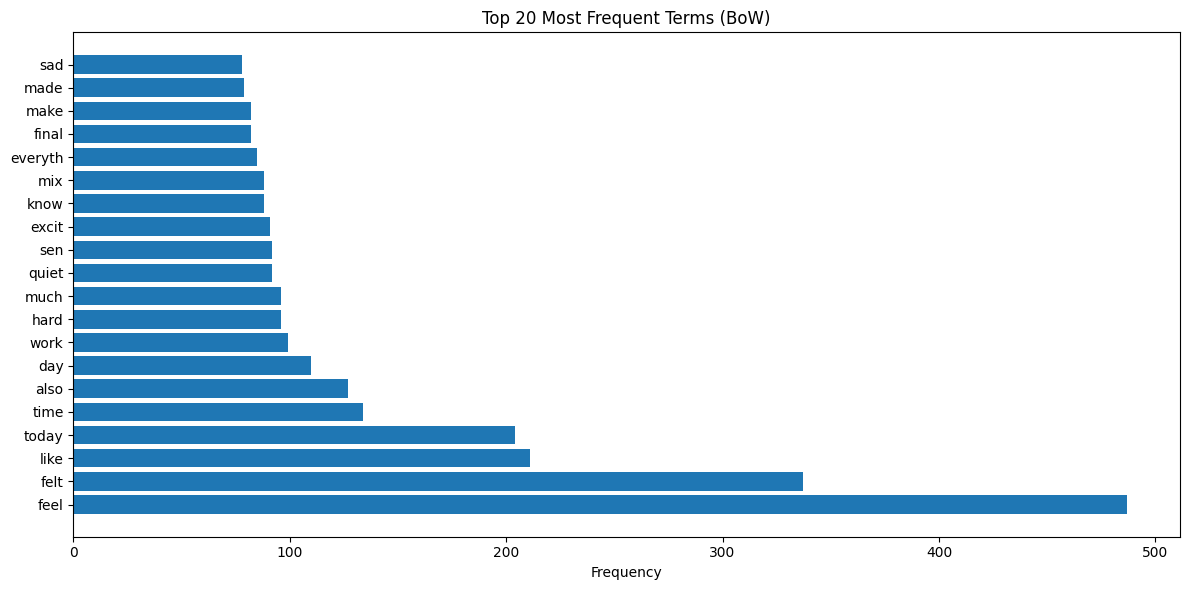

In [288]:
# Create a BoW vectorizer and transform the data


bow_vectorizer = CountVectorizer(min_df=2, max_features=5000)
bow_vectorizer.fit(train_processed)

X_train_bow = bow_vectorizer.transform(train_processed)
X_val_bow = bow_vectorizer.transform(val_processed)
X_test_bow = bow_vectorizer.transform(test_processed)

# Analyze the feature space
vocab_size = len(bow_vectorizer.vocabulary_)
feature_density = X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])

print(f"BoW Vocabulary Size: {vocab_size}")
print(f"BoW Feature Matrix Shape: {X_train_bow.shape}")
print(f"Feature Density: {feature_density:.6f}")
print(f"Average Non-Zero Features Per Sample: {X_train_bow.nnz / X_train_bow.shape[0]:.2f}")

# Visualize most common terms
feature_names = bow_vectorizer.get_feature_names_out()
word_counts = np.asarray(X_train_bow.sum(axis=0)).ravel()
word_freq = dict(zip(feature_names, word_counts))

plt.figure(figsize=(12, 6))
top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*top_words)
plt.barh(range(len(words)), counts)
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Terms (BoW)')
plt.tight_layout()
plt.show()

#### 3.2. TF-IDF Feature Extraction

We implemented TF-IDF vectorization with the same parameter settings as BoW for direct comparison.

TF-IDF Vocabulary Size: 1207
TF-IDF Feature Matrix Shape: (1124, 1207)
Feature Density: 0.010237
Average Non-Zero Features Per Sample: 12.36


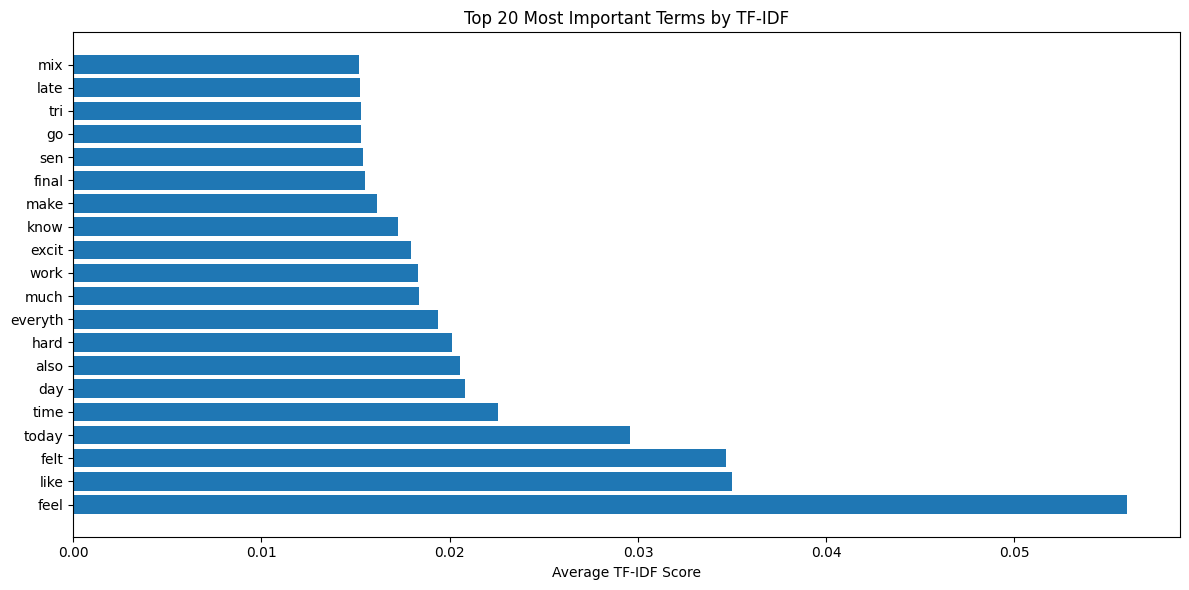

In [289]:
# Create a TF-IDF vectorizer and transform the data
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_features=5000)
tfidf_vectorizer.fit(train_processed)

X_train_tfidf = tfidf_vectorizer.transform(train_processed)
X_val_tfidf = tfidf_vectorizer.transform(val_processed)
X_test_tfidf = tfidf_vectorizer.transform(test_processed)

# Analyze the feature space
vocab_size = len(tfidf_vectorizer.vocabulary_)
feature_density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])

print(f"TF-IDF Vocabulary Size: {vocab_size}")
print(f"TF-IDF Feature Matrix Shape: {X_train_tfidf.shape}")
print(f"Feature Density: {feature_density:.6f}")
print(f"Average Non-Zero Features Per Sample: {X_train_tfidf.nnz / X_train_tfidf.shape[0]:.2f}")

# Find most important terms by highest average TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_avg = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
tfidf_importance = dict(zip(feature_names, tfidf_avg))

plt.figure(figsize=(12, 6))
top_words = sorted(tfidf_importance.items(), key=lambda x: x[1], reverse=True)[:20]
words, importance = zip(*top_words)
plt.barh(range(len(words)), importance)
plt.yticks(range(len(words)), words)
plt.xlabel('Average TF-IDF Score')
plt.title('Top 20 Most Important Terms by TF-IDF')
plt.tight_layout()
plt.show()

#### 3.3 Comparison

We observe similar sparsity levels between BoW and TF-IDF representations, which is expected since they share the same vocabulary. However, the distribution of feature magnitudes differs significantly.

TF-IDF values are more normalized, with lower magnitude sums per document, reflecting the downweighting of common terms. This normalization helps prevent common but emotionally neutral words from dominating the feature space, which is particularly beneficial for emotion classification tasks.

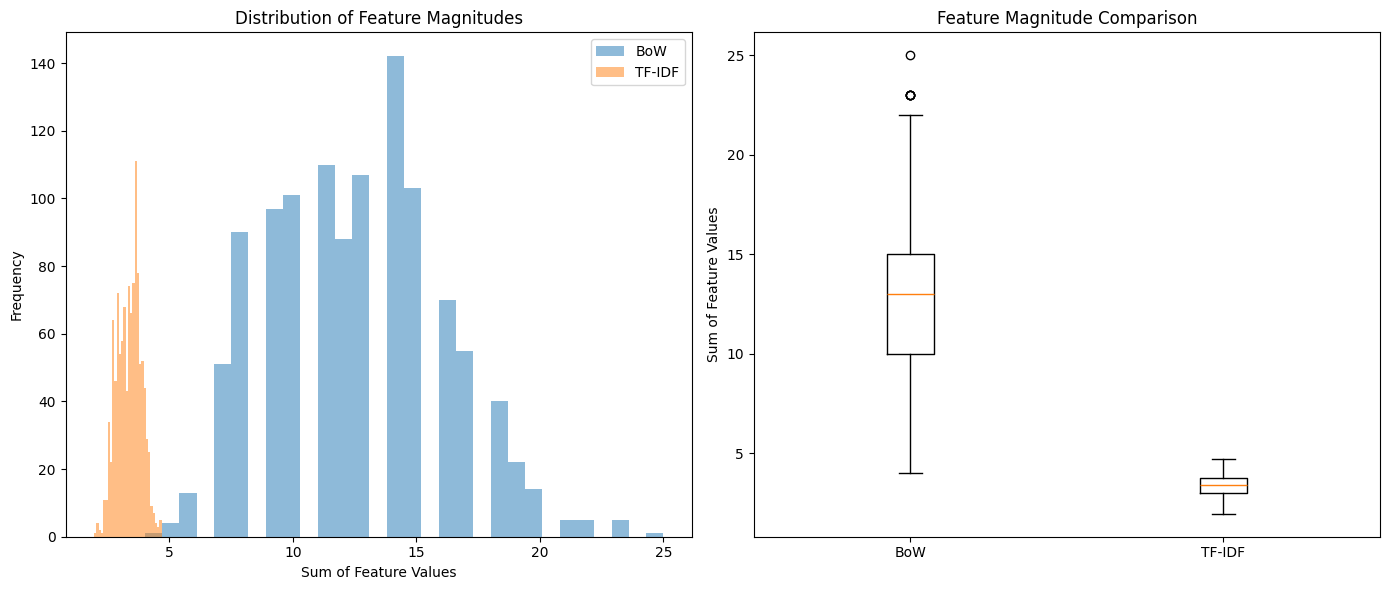

BoW Sparsity: 0.989763
TF-IDF Sparsity: 0.989763


In [290]:
# Function to compare sparsity and distributions
def compare_feature_representations(X_bow, X_tfidf):
    # Sparsity
    # The formula calculates the percentage of zero values (sparsity) in each matrix
    # Higher sparsity means fewer non-zero elements in the feature matrix
    # X_bow.nnz and X_tfidf.nnz represent the number of non-zero elements in each sparse matrix
    # X_bow.shape[0] * X_bow.shape[1] calculates the total number of elements (rows × columns)
    bow_sparsity = 1.0 - (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))
    tfidf_sparsity = 1.0 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))
    
    # Feature magnitudes
    # Sums all feature values for each document (row) in the matrices
    # sum(axis=1) adds up values across columns (features) for each row
    # flatten() converts the result into a 1D array
    # These magnitudes represent the "total weight" of all features for each document
    bow_magnitudes = np.asarray(X_bow.sum(axis=1)).flatten()
    tfidf_magnitudes = np.asarray(X_tfidf.sum(axis=1)).flatten()
    
    # Plot distributions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Histogram of feature magnitudes
    ax1.hist(bow_magnitudes, alpha=0.5, label='BoW', bins=30)
    ax1.hist(tfidf_magnitudes, alpha=0.5, label='TF-IDF', bins=30)
    ax1.set_title('Distribution of Feature Magnitudes')
    ax1.set_xlabel('Sum of Feature Values')
    ax1.set_ylabel('Frequency')
    ax1.legend()
    
    # Boxplot of feature magnitudes
    ax2.boxplot([bow_magnitudes, tfidf_magnitudes], tick_labels=['BoW', 'TF-IDF'])
    ax2.set_title('Feature Magnitude Comparison')
    ax2.set_ylabel('Sum of Feature Values')
    
    plt.tight_layout()
    plt.show()
    
    return bow_sparsity, tfidf_sparsity

bow_sparsity, tfidf_sparsity = compare_feature_representations(X_train_bow, X_train_tfidf)
print(f"BoW Sparsity: {bow_sparsity:.6f}")
print(f"TF-IDF Sparsity: {tfidf_sparsity:.6f}")

**Histogram**: Shows the distribution of feature magnitude sums across documents

**Boxplot**: Provides a statistical summary of the distribution differences

Sparsity Results
- Both BoW and TF-IDF matrices have high sparsity (=99%)
- High sparsity values indicate that most elements in both matrices are zeros
This is expected because most documents only contain a small subset of the entire vocabulary

#### 3.4 Applying TF-IDF Vectorization

We will now vectorize the text column values from our dataset using a TF-IDF vectorizer, in order to weigh words based on their importance relative to the entire corpus

In [291]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1, 2))

# Fit and transform the text column for training set, then transform validation & test sets
text_train_tfidf = vectorizer.fit_transform(train_df["text"])
text_val_tfidf = vectorizer.transform(val_df["text"])
text_test_tfidf = vectorizer.transform(test_df["text"])

# Convert sparse matrices to dense DataFrames
train_tfidf = pd.DataFrame(text_train_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
val_tfidf = pd.DataFrame(text_val_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
test_tfidf = pd.DataFrame(text_test_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

# Concatenate the original DataFrame (excluding the text column, as it's now vectorized)
train_tfidf = pd.concat([train_df.drop(columns=["text"]).reset_index(drop=True), train_tfidf], axis=1)
val_tfidf = pd.concat([val_df.drop(columns=["text"]).reset_index(drop=True), val_tfidf], axis=1)
test_tfidf = pd.concat([test_df.drop(columns=["text"]).reset_index(drop=True), test_tfidf], axis=1)


---

## 4. Text Vectorization using Word2Vec

#### 4.1. Word2Vec Model Training

We started by converting the "text" column values into lists of words, and then training the Word2Vec model using these lists.

In [292]:
# Convert cleaned text into tokenized sentences (lists of words)
sentences = train_df['text'].apply(lambda x: x.split()).tolist()

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=sentences,  # Tokenized text
    vector_size=100,      # Dimensionality of word embeddings
    window=5,             # Context window size
    min_count=2,          # Ignore words with frequency lower than 2
    workers=4,            # Number of parallel threads
    sg=1                  # Use Skip-gram (sg=1), use CBOW (sg=0)
)

#### 4.2. Convert Text Data into Word2Vec Embeddings

With the model trained, we were then able to convert our entire "text" colum from the dataset into numerical vectors.

In [295]:
import numpy as np
import pandas as pd

def vectorize_text(text, model):
    words = text.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)  # Return a zero vector if no words exist in the model
    
    return np.mean(word_vectors, axis=0)  # Average word vectors

# Apply the function to create feature vectors for all sentences
text_train_w2v = np.array(train_df['text'].apply(lambda x: vectorize_text(x, word2vec_model)).tolist())
text_val_w2v = np.array(val_df['text'].apply(lambda x: vectorize_text(x, word2vec_model)).tolist())
text_test_w2v = np.array(test_df['text'].apply(lambda x: vectorize_text(x, word2vec_model)).tolist())

# Create DataFrames from the NumPy arrays
train_vectors_df = pd.DataFrame(text_train_w2v, columns=[f'vec_{i}' for i in range(text_train_w2v.shape[1])])
val_vectors_df = pd.DataFrame(text_val_w2v, columns=[f'vec_{i}' for i in range(text_val_w2v.shape[1])])
test_vectors_df = pd.DataFrame(text_test_w2v, columns=[f'vec_{i}' for i in range(text_test_w2v.shape[1])])

# Drop the text column and concatenate with other columns
train_w2v = pd.concat([train_df.drop(columns=['text']).reset_index(drop=True), train_vectors_df], axis=1)
val_w2v = pd.concat([val_df.drop(columns=['text']).reset_index(drop=True), val_vectors_df], axis=1)
test_w2v = pd.concat([test_df.drop(columns=['text']).reset_index(drop=True), test_vectors_df], axis=1)

print(train_w2v.head())


   primary_emotion  secondary_emotions  \
0             1.00                0.75   
1             0.75                1.00   
2             0.25                0.25   
3             0.00                0.25   
4             1.00                0.50   

                                       meta_emotions sentiment  \
0  ['Reflection on courage', 'Commitment to creat...  Positive   
1  ['Reflection on emotional resilience', 'Commit...  Positive   
2  ['Reflection on growth', 'Commitment to learni...     Mixed   
3  ['Reflection on past memories', 'Acceptance of...     Mixed   
4  ['Reflection on growth', 'Commitment to self-i...  Positive   

   interaction_style  intensity  context     vec_0     vec_1     vec_2  ...  \
0               0.00        0.8     1.00 -0.046984  0.142477  0.077596  ...   
1               1.00        0.8     0.75 -0.047405  0.155871  0.076673  ...   
2               0.75        0.7     0.75 -0.045661  0.153059  0.079595  ...   
3               0.25        0.8   

---

## 5. Classifier Model Training

In [296]:
#drop meta-emotions for now, undo this when meta_emotions are converted to number
train_tfidf = train_tfidf.drop(columns=["meta_emotions"])
val_tfidf = val_tfidf.drop(columns=["meta_emotions"])
test_tfidf = test_tfidf.drop(columns=["meta_emotions"])

X_train_tfidf = train_tfidf.drop(columns=["sentiment"]).values
X_val_tfidf = val_tfidf.drop(columns=["sentiment"]).values
X_test_tfidf = test_tfidf.drop(columns=["sentiment"]).values

In [297]:
train_w2v = train_w2v.drop(columns=["meta_emotions"])
val_w2v = val_w2v.drop(columns=["meta_emotions"])
test_w2v = test_w2v.drop(columns=["meta_emotions"])

X_train_w2v = train_w2v.drop(columns=["sentiment"]).values
X_val_w2v = val_w2v.drop(columns=["sentiment"]).values
X_test_w2v = test_w2v.drop(columns=["sentiment"]).values

#### 5.1. Preparing Data and Labels for Model Training
We started by preparing the necessary data and labels for training, namely converting the labels into integer numerical values. 

In [298]:
# Convert labels to numerical format, has to be integers
label_mapping = {"Negative": 0, "Ambiguous": 1, "Neutral": 2, "Mixed": 3, "Positive": 4}

def label_to_num(df):
    new_labels = []
    for label in df:
        new_labels.append(label_mapping[label])
    return new_labels

In [299]:
y_train_tfidf = np.array(label_to_num(train_df["sentiment"]))
y_val_tfidf = np.array(label_to_num(val_df["sentiment"]))
y_test_tfidf = np.array(label_to_num(test_df["sentiment"]))

print(X_test_tfidf.shape, y_test_tfidf.shape)

(375, 11815) (375,)


In [300]:
y_train_w2v = np.array(label_to_num(train_df["sentiment"]))
y_val_w2v = np.array(label_to_num(val_df["sentiment"]))
y_test_w2v = np.array(label_to_num(test_df["sentiment"]))

print(X_test_w2v.shape, y_test_w2v.shape)

(375, 105) (375,)


#### 5.2. Classifier Model Training for TF-IDF
Then we trained several classifiers using the preprocessed dataset.

In [275]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Initialize models
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel="linear"),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Train and evaluate models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train_tfidf)
    
    # Evaluate on validation set
    y_pred = model.predict(X_val_tfidf)
    accuracy = accuracy_score(y_val_tfidf, y_pred)
    
    print(f"{name} Validation Accuracy: {accuracy:.4f}\n")


Training Naive Bayes...
Naive Bayes Validation Accuracy: 0.7147

Training Logistic Regression...
Logistic Regression Validation Accuracy: 0.7093

Training Decision Tree...
Decision Tree Validation Accuracy: 0.6400

Training Random Forest...
Random Forest Validation Accuracy: 0.7200

Training SVM...
SVM Validation Accuracy: 0.7547

Training MLP...
MLP Validation Accuracy: 0.7733

Training XGBoost...


/opt/miniconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:06:33] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Validation Accuracy: 0.7280



Finally, we identified the model that performed best, in this case MLP, and applied it to the test dataset.

In [276]:
best_model = models["MLP"]  

y_test_pred = best_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test_tfidf, y_test_pred)

print(f"Test Accuracy of Best Model ({best_model}): {test_accuracy:.4f}")

Test Accuracy of Best Model (MLPClassifier(max_iter=500)): 0.7600


#### 5.3. Classifier Model Training for Word2Vector
Then we repeated the model training and evaluation using the dataset vectorized with Word2Vector model.

In [301]:
# Train and evaluate models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_w2v, y_train_w2v)
    
    # Evaluate on validation set
    y_pred = model.predict(X_val_w2v)
    accuracy = accuracy_score(y_val_w2v, y_pred)
    
    print(f"{name} Validation Accuracy: {accuracy:.4f}\n")

Training Naive Bayes...
Naive Bayes Validation Accuracy: 0.4773

Training Logistic Regression...
Logistic Regression Validation Accuracy: 0.6107

Training Decision Tree...
Decision Tree Validation Accuracy: 0.6027

Training Random Forest...
Random Forest Validation Accuracy: 0.7013

Training SVM...
SVM Validation Accuracy: 0.5973

Training MLP...


/opt/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:10:54] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


MLP Validation Accuracy: 0.6960

Training XGBoost...
XGBoost Validation Accuracy: 0.7307



Finally, we identified the model that performed best, in this case MLP, and applied it to the test dataset.

In [303]:
best_model = models["XGBoost"]  

y_test_pred = best_model.predict(X_test_w2v)
test_accuracy = accuracy_score(y_test_w2v, y_test_pred)

print(f"Test Accuracy of Best Model ({best_model}): {test_accuracy:.4f}")

Test Accuracy of Best Model (XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)): 0.6800
